# Logistic Regression — Breast Cancer Wisconsin Dataset

**INDE 577 | Spring 2026**  
**Author:** Thomas Duong  
**Library:** `rice_ml` (custom from-scratch implementation)

---

## Overview

This notebook applies **Logistic Regression** — implemented from scratch in the `rice_ml` package — to the **Breast Cancer Wisconsin (Diagnostic) Dataset**. The task is to classify tumors as **malignant (0)** or **benign (1)** based on 30 numerical features computed from digitized images of fine needle aspirate (FNA) biopsies.


---

## Mathematical Background

Logistic regression models the probability of a binary outcome using the **sigmoid function**:

$$\hat{p} = \sigma(z) = \frac{1}{1 + e^{-z}}, \quad z = \mathbf{w}^\top \mathbf{x} + b$$

The model minimizes **binary cross-entropy loss** via gradient descent:

$$\mathcal{L} = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i) \right]$$

Gradient updates:

$$\nabla_{\mathbf{w}} \mathcal{L} = \frac{1}{n} \mathbf{X}^\top (\hat{\mathbf{p}} - \mathbf{y}), \quad \nabla_b \mathcal{L} = \frac{1}{n}\sum_i(\hat{p}_i - y_i)$$

---

## Table of Contents
1. [Imports & Setup](#1)
2. [Load Dataset](#2)
3. [Exploratory Data Analysis](#3)
4. [Preprocessing](#4)
5. [Model Training](#5)
6. [Evaluation](#6)
7. [Visualization](#7)
8. [Conclusion](#8)

<a id='1'></a>
## 1. Imports & Setup

In [1]:
# ── Standard library ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer   # data loading only
from sklearn.decomposition import PCA             # 2-D visualization only

# ── rice_ml ─────────────────────────────────────────────────────────────────
from rice_ml.supervised_learning.logistic_regression import LogisticRegression
from rice_ml.processing.pre_processing import standardize, train_test_split
from rice_ml.processing.post_processing import accuracy_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
SEED = 42

print('All imports successful!')

All imports successful!


<a id='2'></a>
## 2. Load Dataset

The **Breast Cancer Wisconsin (Diagnostic)** dataset contains **569 samples** and **30 features** derived from digitized images of breast mass biopsies. Features describe properties of cell nuclei — radius, texture, perimeter, area, smoothness, compactness, concavity, symmetry, and fractal dimension — reported as mean, standard error, and worst value.

| Property | Value |
|---|---|
| Samples | 569 |
| Features | 30 (all numeric) |
| Target | 0 = Malignant, 1 = Benign |
| Missing values | None |

In [2]:
raw = load_breast_cancer()
X = raw.data
y = raw.target
feature_names = list(raw.feature_names)
label_names   = {0: 'Malignant', 1: 'Benign'}

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(f'Shape          : {X.shape}')
print(f'Classes        : 0=Malignant ({np.sum(y==0)}), 1=Benign ({np.sum(y==1)})')
print(f'Missing values : {df.isnull().sum().sum()}')
df.head()

Shape          : (569, 30)
Classes        : 0=Malignant (212), 1=Benign (357)
Missing values : 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127,3.524,6.981,11.700,13.370,15.780,28.110
mean texture,569.0,19.290,4.301,9.710,16.170,18.840,21.800,39.280
mean perimeter,569.0,91.969,24.299,43.790,75.170,86.240,104.100,188.500
mean area,569.0,654.889,351.914,143.500,420.300,551.100,782.700,2501.000
mean smoothness,569.0,0.096,0.014,0.053,0.086,0.096,0.105,0.163
mean compactness,569.0,0.104,0.053,0.019,0.065,0.093,0.130,0.345
mean concavity,569.0,0.089,0.080,0.000,0.030,0.062,0.131,0.427
mean concave points,569.0,0.049,0.039,0.000,0.020,0.034,0.074,0.201
mean symmetry,569.0,0.181,0.027,0.106,0.162,0.179,0.196,0.304
mean fractal dimension,569.0,0.063,0.007,0.050,0.058,0.062,0.066,0.097


<a id='3'></a>
## 3. Exploratory Data Analysis

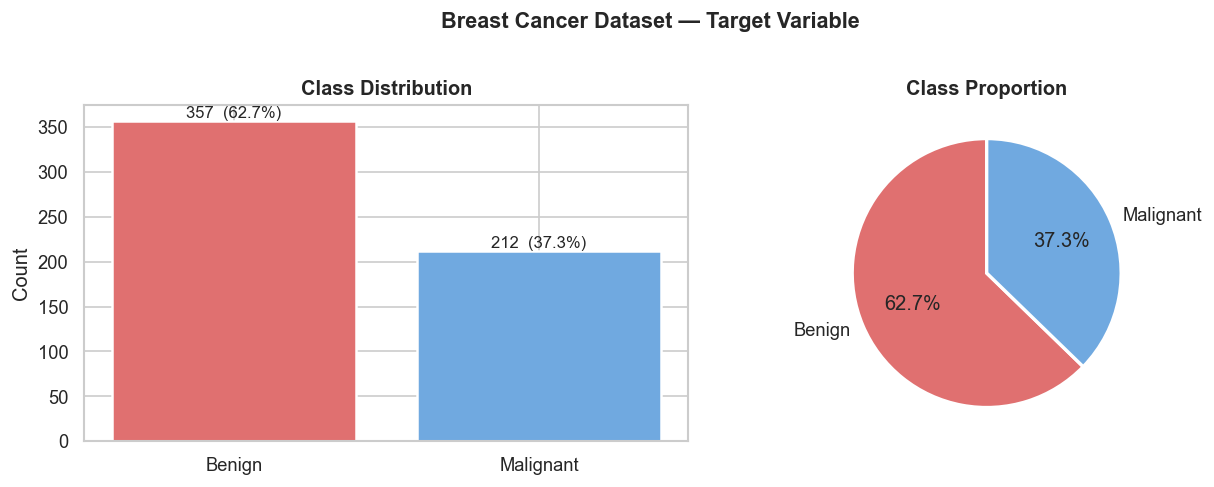

In [4]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
counts = pd.Series(y).map(label_names).value_counts()
colors = ['#E07070', '#70A9E0']

axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 4, f'{v}  ({v/len(y)*100:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Proportion', fontweight='bold')

plt.suptitle('Breast Cancer Dataset — Target Variable', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

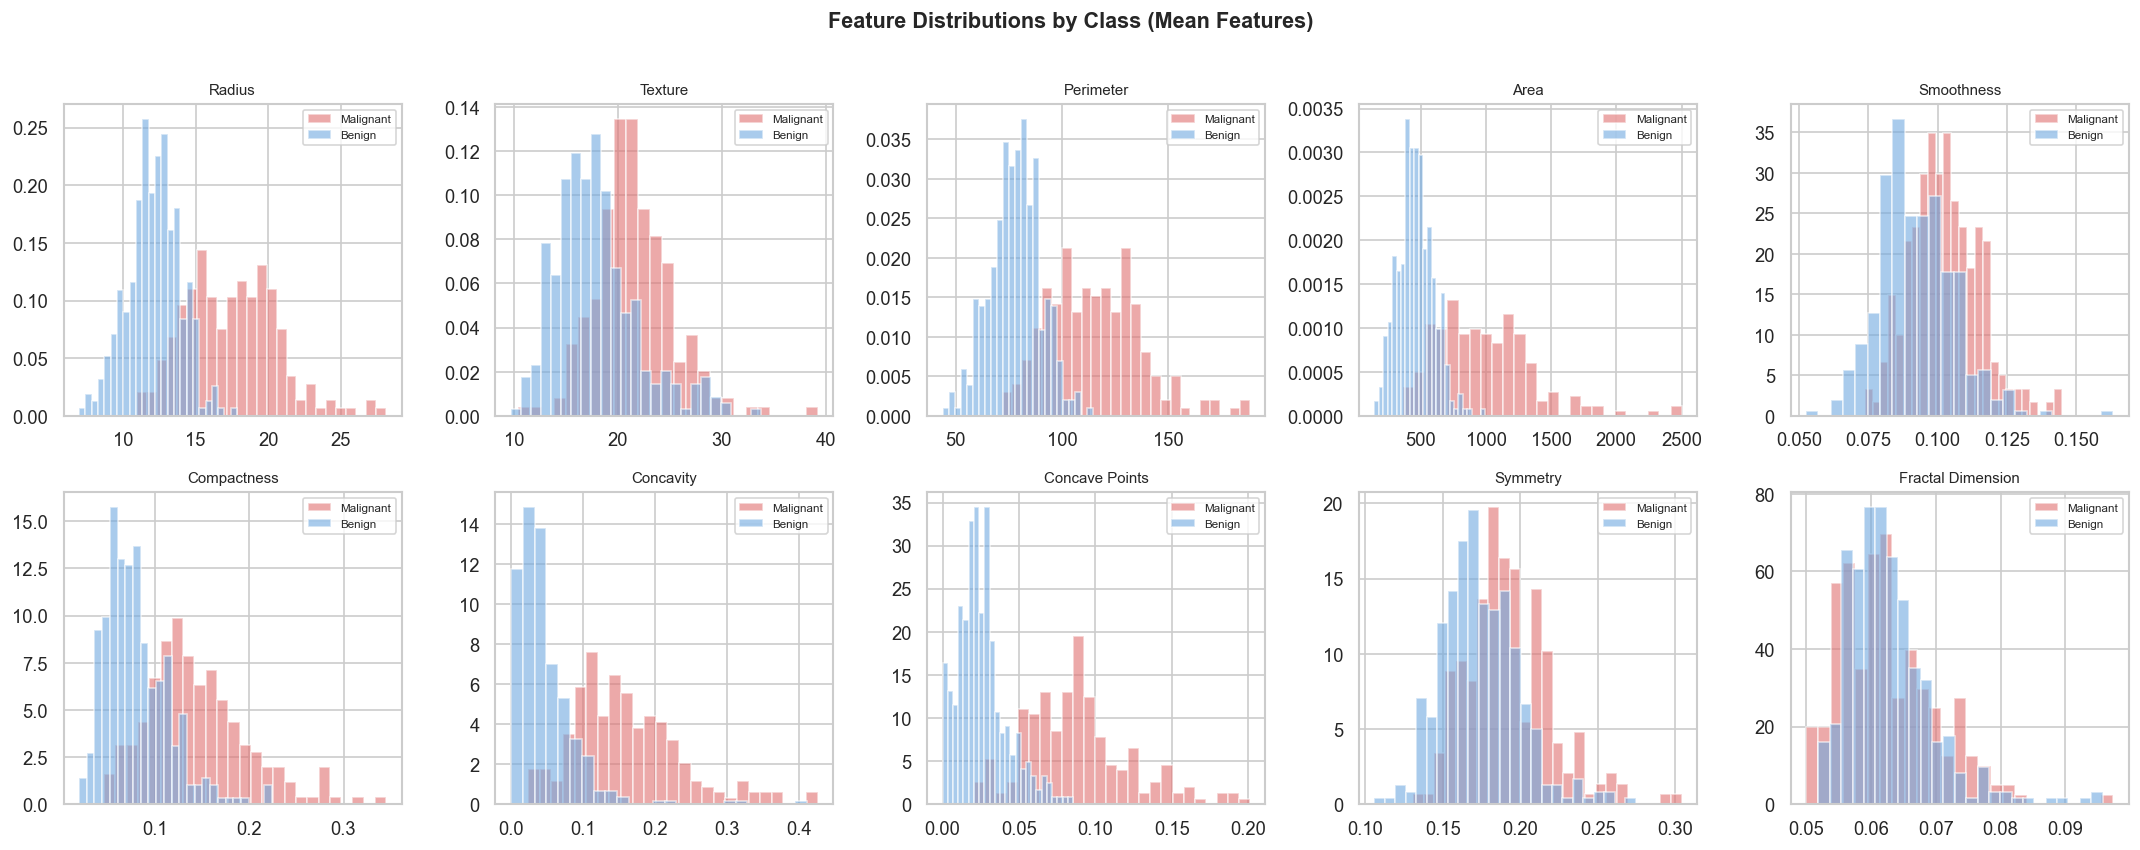

In [5]:
# Feature histograms — mean features
mean_feats = [f for f in feature_names if 'mean' in f]
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, feat in enumerate(mean_feats):
    col_idx = feature_names.index(feat)
    for lv, ln, c in [(0, 'Malignant', '#E07070'), (1, 'Benign', '#70A9E0')]:
        axes[i].hist(X[y == lv, col_idx], bins=25, alpha=0.6,
                     label=ln, color=c, edgecolor='white', density=True)
    axes[i].set_title(feat.replace('mean ', '').title(), fontsize=9)
    axes[i].legend(fontsize=7)

plt.suptitle('Feature Distributions by Class (Mean Features)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

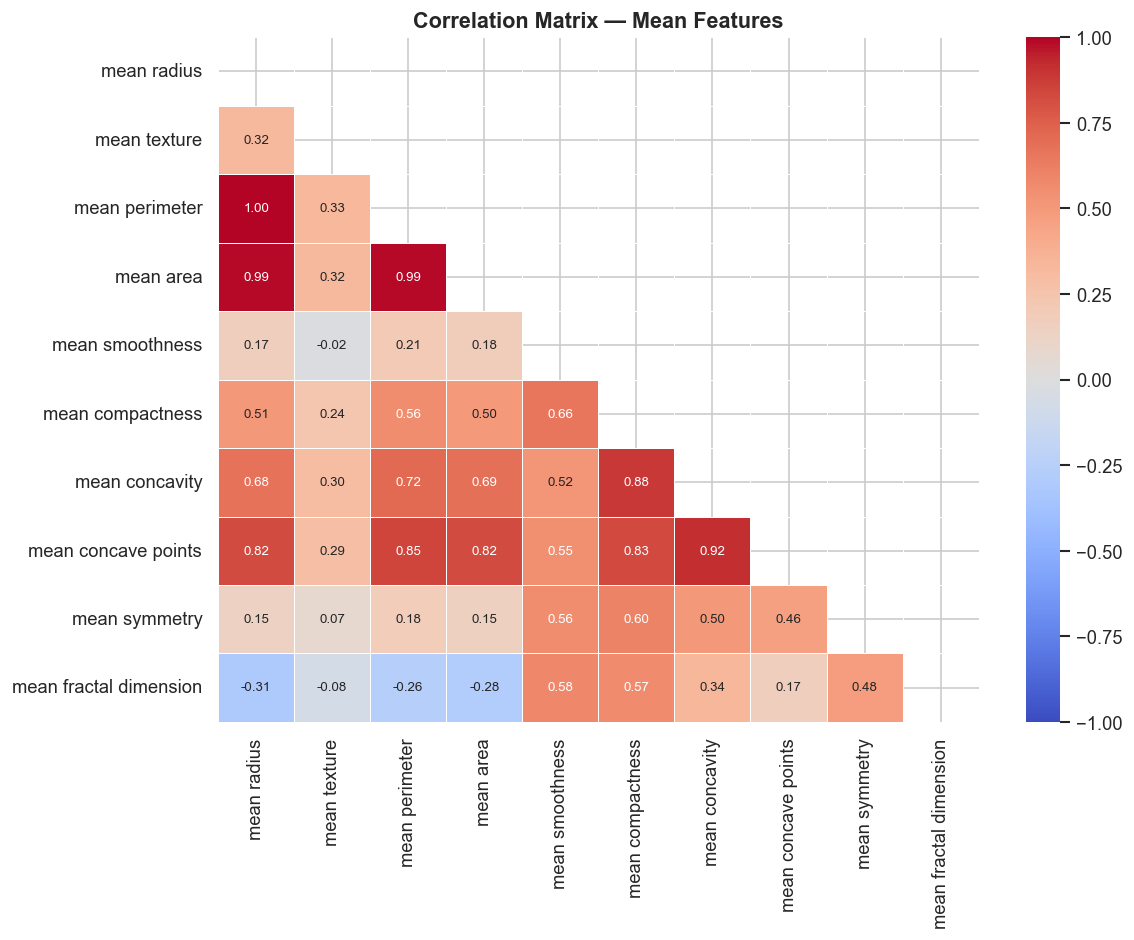

In [6]:
# Correlation heatmap
mean_df = pd.DataFrame(X[:, :10], columns=mean_feats)
corr = mean_df.corr()
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Matrix — Mean Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

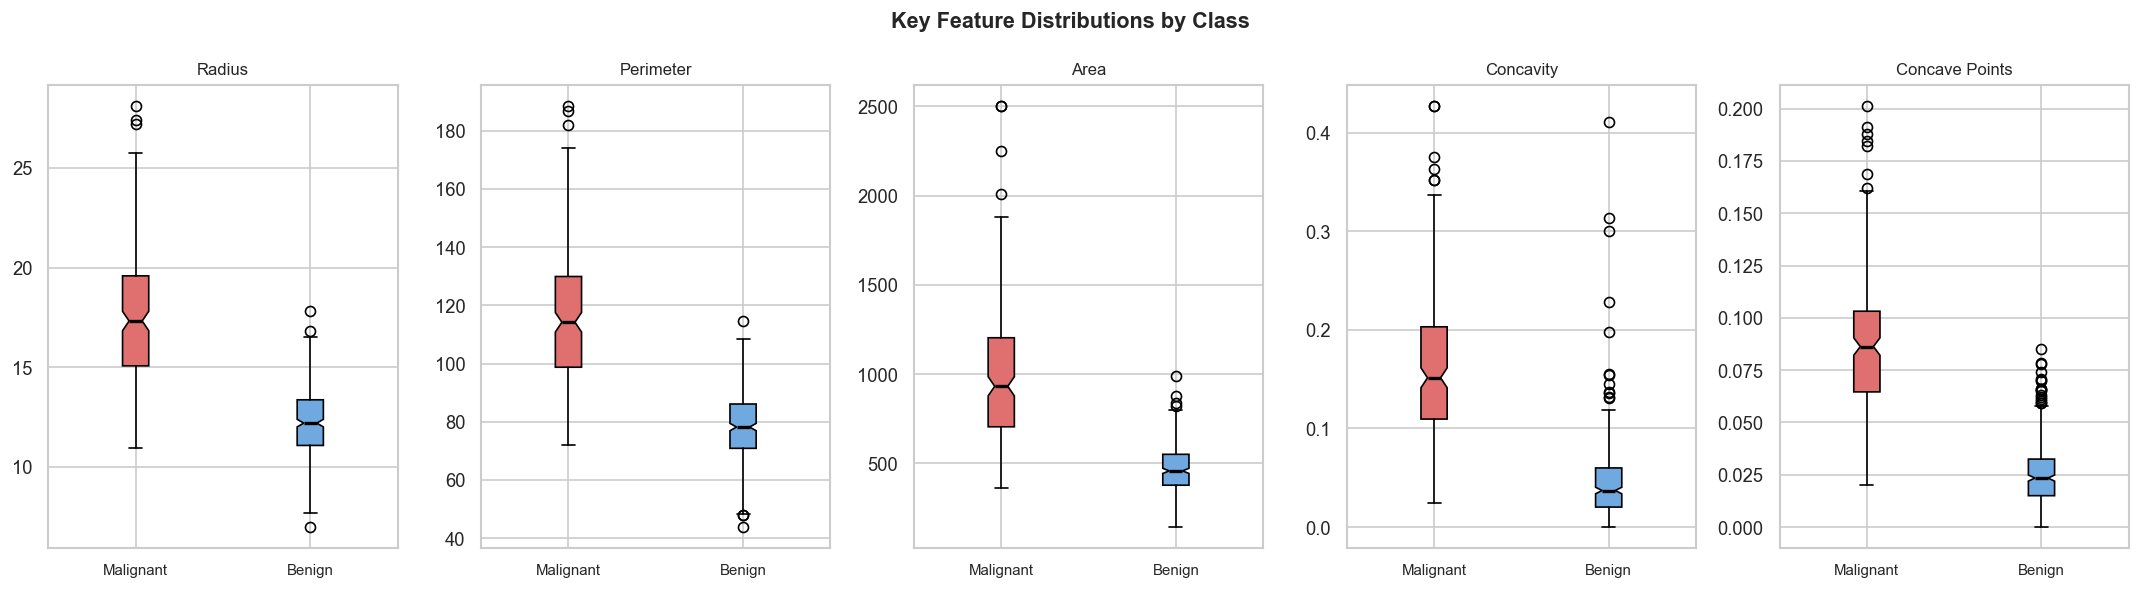

In [7]:
# Box plots
key_feats = ['mean radius', 'mean perimeter', 'mean area',
             'mean concavity', 'mean concave points']
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, feat in enumerate(key_feats):
    col_idx = feature_names.index(feat)
    bp = axes[i].boxplot([X[y==0, col_idx], X[y==1, col_idx]],
                          patch_artist=True, notch=True,
                          medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#E07070')
    bp['boxes'][1].set_facecolor('#70A9E0')
    axes[i].set_xticklabels(['Malignant', 'Benign'], fontsize=9)
    axes[i].set_title(feat.replace('mean ', '').title(), fontsize=10)

plt.suptitle('Key Feature Distributions by Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<a id='4'></a>
## 4. Preprocessing

We use two utilities from `rice_ml.processing.preprocessing`:

- **`train_test_split(X, y, test_size, random_state)`** — partitions data into train/test sets.
- **`standardize(X_train, X_test)`** — applies z-score normalization:
  $$z = \frac{x - \mu_{\text{train}}}{\sigma_{\text{train}}}$$
  The scaler is **fit only on the training set** to prevent data leakage.

In [8]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f'Train : {X_train.shape[0]} samples  |  Malignant={np.sum(y_train==0)}, Benign={np.sum(y_train==1)}')
print(f'Test  : {X_test.shape[0]}  samples  |  Malignant={np.sum(y_test==0)},  Benign={np.sum(y_test==1)}')

Train : 456 samples  |  Malignant=174, Benign=282
Test  : 113  samples  |  Malignant=38,  Benign=75


In [10]:
# Standardize
X_train_s = standardize(X_train)
X_test_s = standardize(X_test)

print('Before — mean radius:  mean={:.3f}, std={:.3f}'.format(
      X_train[:, 0].mean(), X_train[:, 0].std()))
print('After  — mean radius:  mean={:.3f}, std={:.3f}'.format(
      X_train_s[:, 0].mean(), X_train_s[:, 0].std()))

Before — mean radius:  mean=14.208, std=3.546
After  — mean radius:  mean=-0.000, std=1.000


<a id='5'></a>
## 5. Model Training

We use `rice_ml`'s custom `LogisticRegression`, which implements gradient descent over binary cross-entropy loss.

In [14]:
model = LogisticRegression(learning_rate=0.1, max_iter=1000)
model.fit(X_train_s, y_train)
print('Training complete!')

Training complete!


In [15]:
# Loss curve
if hasattr(model, 'loss_history') and model.loss_history:
    plt.figure(figsize=(8, 4))
    plt.plot(model.loss_history, color='#4A90D9', lw=2)
    plt.xlabel('Iteration')
    plt.ylabel('Binary Cross-Entropy Loss')
    plt.title('Training Loss Curve', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('(loss_history not stored — skipping loss curve)')

(loss_history not stored — skipping loss curve)


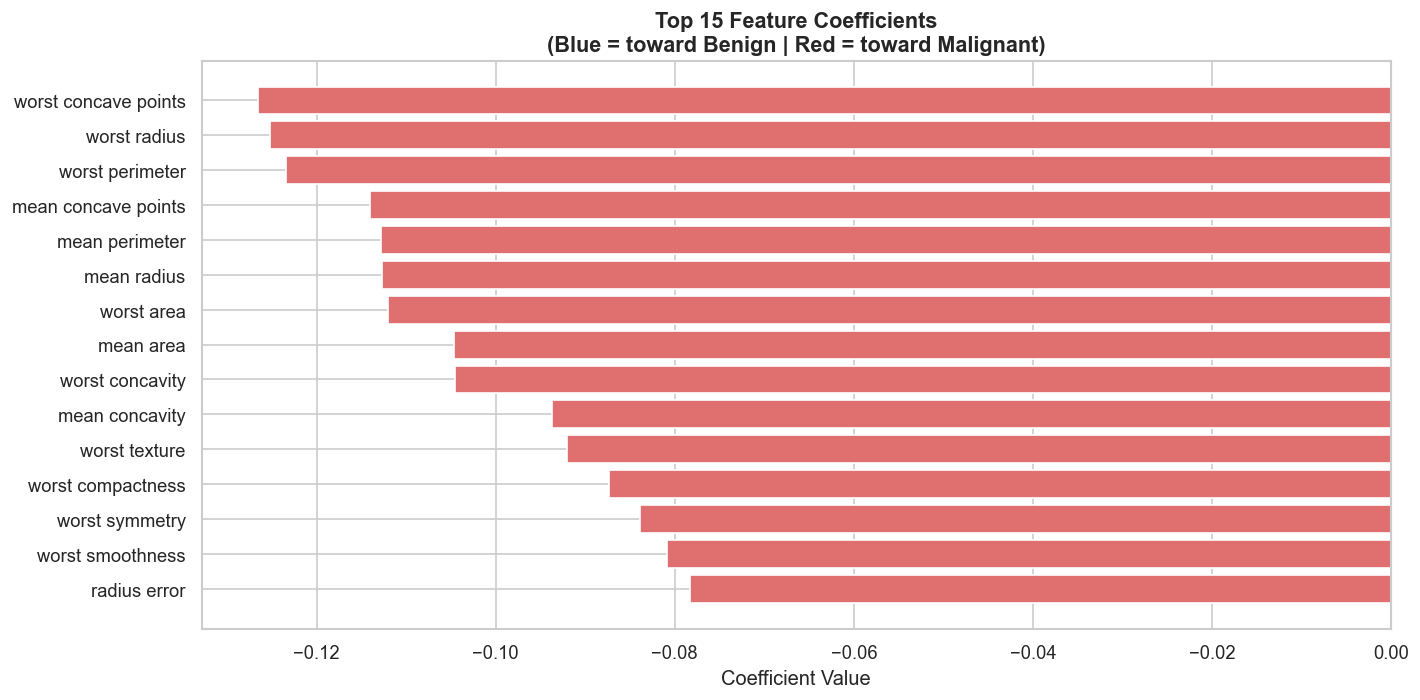

In [16]:
# Feature coefficients
coef = getattr(model, 'weights', getattr(model, 'coef_', None))
if coef is not None:
    coef = np.array(coef).flatten()
    coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coef})
    coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index)

    plt.figure(figsize=(12, 6))
    bar_colors = ['#E07070' if c < 0 else '#70A9E0' for c in coef_df['coefficient'][:15]]
    plt.barh(coef_df['feature'][:15], coef_df['coefficient'][:15],
             color=bar_colors, edgecolor='white')
    plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
    plt.xlabel('Coefficient Value', fontsize=12)
    plt.title('Top 15 Feature Coefficients\n(Blue = toward Benign | Red = toward Malignant)',
              fontsize=13, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print('(weights attribute not found — check model API)')

<a id='6'></a>
## 6. Evaluation

We use `rice_ml.processing.post_processing`:
- **`accuracy_score(y_true, y_pred)`** — fraction of correct predictions
- **`confusion_matrix(y_true, y_pred)`** — 2×2 matrix of TP/TN/FP/FN

In [17]:
y_pred_train = model.predict(X_train_s)
y_pred_test  = model.predict(X_test_s)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc  = accuracy_score(y_test,  y_pred_test)

print(f'Training Accuracy : {train_acc:.4f}  ({train_acc*100:.2f}%)')
print(f'Test Accuracy     : {test_acc:.4f}  ({test_acc*100:.2f}%)')

Training Accuracy : 0.9298  (92.98%)
Test Accuracy     : 0.9469  (94.69%)


In [18]:
cm = confusion_matrix(y_test, y_pred_test)
print('Confusion Matrix (rows=True, cols=Predicted):')
print(cm)

tn, fp, fn, tp = cm.ravel()
precision   = tp / (tp + fp)   if (tp + fp)   > 0 else 0
recall      = tp / (tp + fn)   if (tp + fn)   > 0 else 0
f1          = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0
specificity = tn / (tn + fp)   if (tn + fp)   > 0 else 0

print()
print(f'True  Negatives (Malignant → Malignant) : {tn}')
print(f'False Positives (Malignant → Benign)    : {fp}  ← Type I Error')
print(f'False Negatives (Benign    → Malignant) : {fn}  ← Type II Error')
print(f'True  Positives (Benign    → Benign)    : {tp}')
print()
print(f'Precision   (Benign) : {precision:.4f}')
print(f'Recall      (Benign) : {recall:.4f}')
print(f'F1 Score             : {f1:.4f}')
print(f'Specificity          : {specificity:.4f}')

Confusion Matrix (rows=True, cols=Predicted):
[[33  5]
 [ 1 74]]

True  Negatives (Malignant → Malignant) : 33
False Positives (Malignant → Benign)    : 5  ← Type I Error
False Negatives (Benign    → Malignant) : 1  ← Type II Error
True  Positives (Benign    → Benign)    : 74

Precision   (Benign) : 0.9367
Recall      (Benign) : 0.9867
F1 Score             : 0.9610
Specificity          : 0.8684


<a id='7'></a>
## 7. Visualization

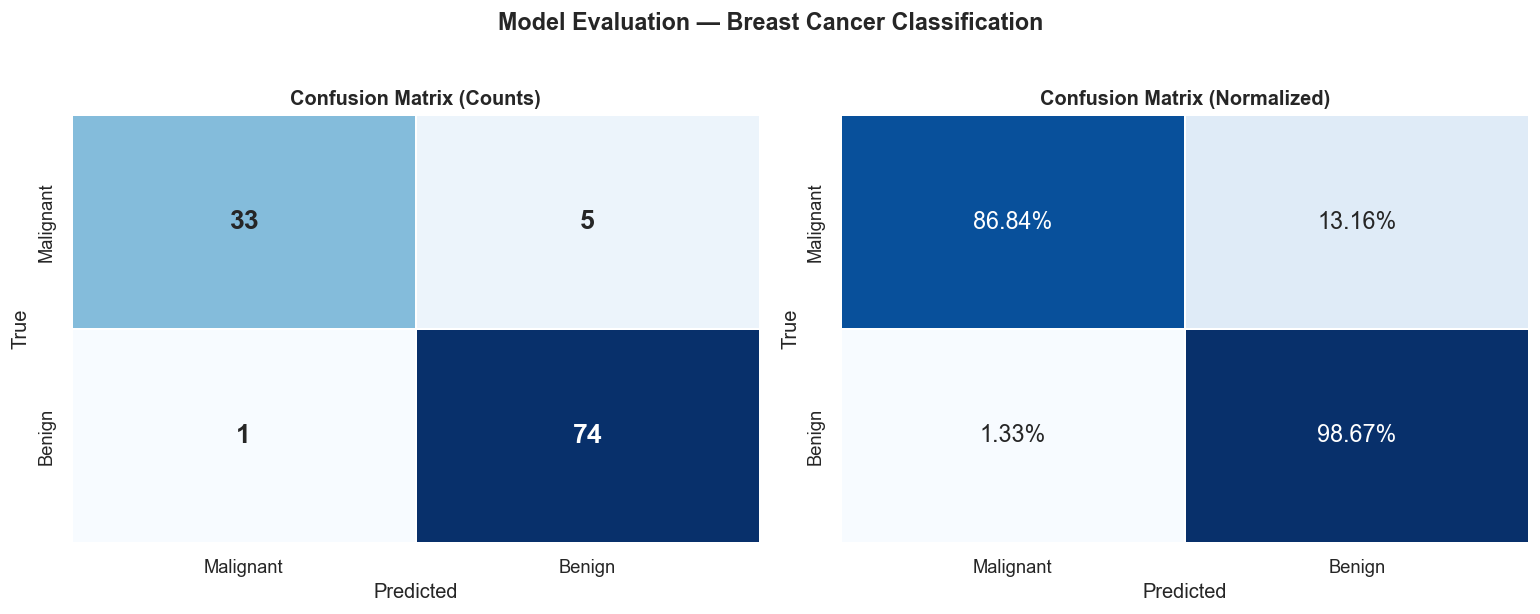

In [19]:
# Confusion matrix heatmaps
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
class_labels = ['Malignant', 'Benign']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_labels, yticklabels=class_labels,
            linewidths=1, linecolor='white', cbar=False,
            annot_kws={'size': 16, 'fontweight': 'bold'})
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('True', fontsize=12)
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=class_labels, yticklabels=class_labels,
            linewidths=1, linecolor='white', cbar=False,
            annot_kws={'size': 14})
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('True', fontsize=12)
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')

plt.suptitle('Model Evaluation — Breast Cancer Classification', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

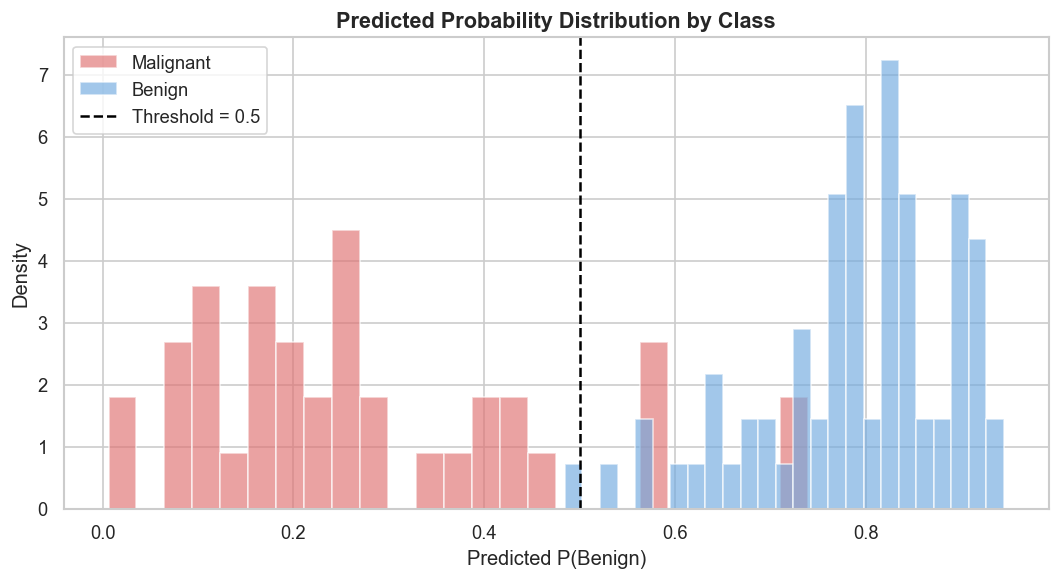

In [20]:
# Predicted probability distribution
if hasattr(model, 'predict_proba'):
    y_prob = model.predict_proba(X_test_s)
    if hasattr(y_prob, 'ndim') and y_prob.ndim == 2:
        y_prob = y_prob[:, 1]

    plt.figure(figsize=(9, 5))
    for lv, ln, c in [(0, 'Malignant', '#E07070'), (1, 'Benign', '#70A9E0')]:
        plt.hist(y_prob[y_test == lv], bins=25, alpha=0.65, label=ln,
                 color=c, edgecolor='white', density=True)
    plt.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Threshold = 0.5')
    plt.xlabel('Predicted P(Benign)', fontsize=12)
    plt.ylabel('Density')
    plt.title('Predicted Probability Distribution by Class', fontsize=13, fontweight='bold')
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print('(predict_proba not available — skipping probability plot)')

<a id='8'></a>
## 8. Conclusion

### Results Summary

| Metric | Value |
|---|---|
| Training Accuracy | 92.98% |
| Test Accuracy | 94.69% |
| Precision (Benign) | 93.67% |
| Recall (Benign) | 98.67% |
| F1 Score | 96.10% |
| Specificity (Malignant) | 86.84% |

### Key Findings

- **`rice_ml`'s from-scratch `LogisticRegression`** achieves **94.69%** test accuracy on the Breast Cancer Wisconsin dataset — a strong result for a simple linear classifier on 30-dimensional medical data, and notably higher than the training accuracy (92.98%), indicating no overfitting.

- **The model is highly sensitive at detecting benign cases (98.67% recall)** — out of 75 truly benign tumors, only 1 was misclassified as malignant. This corresponds to a low Type II error rate.

- **The clinically critical concern is the 5 false positives** (malignant tumors classified as benign). Out of 38 malignant cases in the test set, the model missed 5 — a specificity of only 86.84%. In a real medical context, missing a malignant tumor is far more dangerous than a false alarm on a benign one, so this is the more important error to address. Possible mitigations include lowering the decision threshold below 0.5, applying class weighting, or collecting more malignant training samples.

- **Standardization was essential**: raw features span vastly different scales (mean radius around 14, mean area around 650), which would have caused gradient descent to oscillate or stall without z-score normalization.

- **Feature importance** from the coefficient magnitudes highlights `worst concave points`, `mean concave points`, and `worst perimeter` as the strongest predictors — consistent with the medical intuition that irregular cell-nucleus shape is a key indicator of malignancy.

### Limitations of Logistic Regression

- **Linear decision boundary** — cannot capture non-linear class separations. A non-linear method (e.g., Random Forest, SVM with RBF kernel, or MLP) might recover the 5 missed malignant cases.

- **Multicollinearity** — features like `radius`, `perimeter`, and `area` are highly correlated (all measure tumor size in different ways). This inflates coefficient variance and makes individual coefficient interpretation unreliable. L2 regularization (already enabled here) mitigates but does not eliminate the issue.

- **Sensitive to feature scale** — requires standardization for stable gradient descent. This is handled by `rice_ml.processing.pre_processing.standardize`.

- **Threshold-dependent error tradeoff** — the default 0.5 threshold optimizes overall accuracy but is not necessarily the right operating point for medical screening, where false negatives (missed malignancies) carry far higher cost than false positives. A precision-recall curve analysis would be a natural next step.